#Import

In [19]:
# Import Libraries

# pandas - used to load and work with tabular data (CSV files, DataFrames)
import pandas as pd

# numpy - used for numerical operations and array handling
import numpy as np

# matplotlib.pyplot - used to create plots and visualizations
import matplotlib.pyplot as plt

# LinearRegression - scikit-learn class to build a simple linear regression model
from sklearn.linear_model import LinearRegression

# Loading

In [20]:
# Load Dataset

# Read scores.csv into a pandas DataFrame (table with Hours and Scores columns)
url = 'https://raw.githubusercontent.com/gulshairkhaqan-hub/student-marks-predictor/main/scores.csv'
df = pd.read_csv(url)

# Show the first 5 rows to understand the data before modeling
print(df.head())

   Hours  Scores
0    2.5      21
1    5.1      47
2    3.2      27
3    8.5      75
4    3.5      30


# processing

In [21]:
# Prepare Data

# Features (X) - the input we use to predict (Hours studied)
# Target (y) - the output we want to predict (Scores)
X = df[['Hours']]
y = df['Scores']

# Training

In [22]:
# Train Model

# Create a linear regression model
model = LinearRegression()

# Training: the model learns the best straight line (coefficient and intercept)
# that fits the relationship between study hours and scores
model.fit(X, y)

# Display the learned line parameters: Score = coefficient * Hours + intercept
print('Coefficient:', model.coef_[0])
print('Intercept:', model.intercept_)

Coefficient: 9.775803390787468
Intercept: 2.48367340537321


# Prediction

In [23]:
# Make Predictions

# Predict scores for all students using the trained model
y_pred = model.predict(X)

# Build a table comparing actual scores with predicted scores
comparison_df = pd.DataFrame({
    'Hours': df['Hours'],
    'Actual Scores': df['Scores'],
    'Predicted Scores': y_pred
})

print(comparison_df)

    Hours  Actual Scores  Predicted Scores
0     2.5             21         26.923182
1     5.1             47         52.340271
2     3.2             27         33.766244
3     8.5             75         85.578002
4     3.5             30         36.698985
5     1.5             20         17.147378
6     9.2             88         92.421065
7     5.5             60         56.250592
8     8.3             81         83.622842
9     2.7             25         28.878343
10    7.7             85         77.757360
11    5.9             62         60.160913
12    4.5             41         46.474789
13    3.3             42         34.743825
14    1.1             17         13.237057
15    8.9             95         89.488324
16    2.5             30         26.923182
17    1.9             24         21.057700
18    6.1             67         62.116074
19    7.4             69         74.824618
20    2.7             30         28.878343
21    4.8             54         49.407530
22    3.8  

# Evaluatioin

In [24]:
# Model Evaluation: How well do predictions match actual scores?

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# MAE (Mean Absolute Error) - average size of prediction errors in score points
# Lower is better; easy to interpret (e.g., "off by about 4 points on average")
mae = mean_absolute_error(y, y_pred)

# MSE (Mean Squared Error) - average of squared errors; penalizes large mistakes more
# Lower is better; not in the same units as scores because errors are squared
mse = mean_squared_error(y, y_pred)

# RMSE (Root Mean Squared Error) - square root of MSE; back in score units like MAE
# Lower is better; sensitive to outliers, similar scale to actual scores
rmse = np.sqrt(mse)

# R² (R-squared) - how much variance in scores the model explains (0 to 1 typical)
# Closer to 1 is better; 1 means perfect fit, 0 means no better than predicting the mean
r2 = r2_score(y, y_pred)

print(f'MAE:  {mae:.2f}')
print(f'MSE:  {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²:   {r2:.4f}')

MAE:  4.97
MSE:  28.88
RMSE: 5.37
R²:   0.9529


# Prediction

Enter hours studied (1-10): 9.8
Predicted score for 9.8 hours: 98.29


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


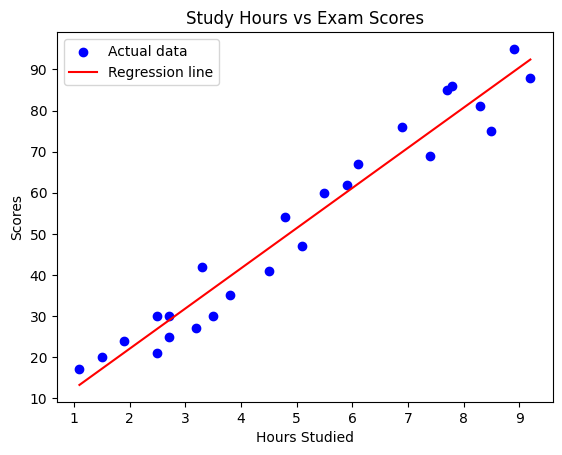

In [25]:
# Custom Prediction + Plot

# Predict the score for a student who studies 9.25 hours per day
hours_studied = float(input("Enter hours studied (1-10): "))

if hours_studied < 1 or hours_studied > 10:
    print("Warning: Value is outside training range (1-10). Prediction may not be accurate.")
else:
    predicted_score = model.predict([[hours_studied]])
    print(f'Predicted score for {hours_studied} hours: {predicted_score[0]:.2f}')

# Visualization: scatter plot shows actual data; line shows the regression model
plt.scatter(df['Hours'], df['Scores'], color='blue', label='Actual data')

# Draw the regression line across the range of study hours
line_x = np.linspace(df['Hours'].min(), df['Hours'].max(), 100).reshape(-1, 1)
line_y = model.predict(line_x)
plt.plot(line_x, line_y, color='red', label='Regression line')

plt.title('Study Hours vs Exam Scores')
plt.xlabel('Hours Studied')
plt.ylabel('Scores')
plt.legend()
plt.show()